In [2]:
# Imports and settings
import pandas as pd
import os
import numpy as np
import pycountry
import pyreadstat
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium

warnings.filterwarnings("ignore")
cluster_colors = [
    "#636EFA", "#EF553B", "#00CC96",
    "#AB63FA", "#FFA15A", "#19D3F3",
    "#FF6692", "#B6E880",
]

# Explainer Notebook, DTU 02467 Social Graphs and Interactions (2026) Group 68

# 1. Motivation

## The Paradox of Happiness
We investigate the "Paradox of Happiness" by exploring how the World Happiness Index relates to income inequality (GINI Index), economic stability (unemployment rate), mental-health interventions (antidepressant consumption), and surveys about social connection and trust between citizens of each country (ESS survey), for the period **2015–2020**.

**Research Question:** *Is happiness real — or is it medicated?*

### Datasets
| # | Dataset | Source | Key Metric |
|---|---------|--------|------------|
| 1 | World Happiness Report | WHR / Kaggle | Happiness Score (0–10) |
| 2 | GINI Index | World Bank | Income inequality (0–100) |
| 3 | Unemployment Rate | World Bank (ILO est.) | % of labour force |
| 4 | Antidepressant Consumption | OECD | DDD per 1 000 inh./day ¹ |
| 5 | European Social Survey (ESS) Round 9 | ESS ERIC (2018) | Institutional Trust & Social Connection composites |

> ¹ **DDD** (Defined Daily Dose) is the (World Health Organization) W.H.O. standard unit for drug consumption. A value of e.g. 50 DDD/1 000 inh./day means that on a day, 50 out of every 1 000 people are taking one full maintenance dose of an antidepressant. It normalizes across different drugs and dosages, enabling equal cross-country comparison.

### Why These Datasets?

The **World Happiness Report** is the most widely cited dataset. The **OECD antidepressant data** was chosen because it is the only publicly available, harmonized dataset on psychiatric medication consumption at country level. The **World Bank GINI and unemployment rate** data provide the two structural economic indicators, often used in happiness research. Finally, the **European Social Survey Round 9** was added to move beyond correlation: its validated trust and social-connectedness data allow us to expand the search on this paradox.

The 2015–2020 window was chosen because it is the longest period for which all five sources were overlapping.

### User Experience Goal

A normal person should be able to scroll through the web story and be able to interpret the data alone, without the need of big statistical knowledge. A more educated reader can then use the interactive bubble chart to test their own hypotheses by swapping the x-axis between economic and ESS variables. Both audiences should have an understanding that high antidepressant use in happy countries correlates with more accessible and working healthcare.

# 2. Basic Stats: Data Cleaning, Preprocessing & EDA

Below we load the five datasets, standardise country names, filter to 2015–2020 (as it is the the only suitable range where we have all data avilable), aggregate, and perform an inner join so that only countries with **all variables** are retained.

## 2.1 Inspect the Happiness Excel file
**It's suggested to load and use the pre-cleaned dataset available on GitHub**

Inspect the Happiness dataset to learn its column names and structure.

In [3]:
dataset_files = [ "./data/happiness_paradox_2015_2020.csv", "./data/happiness_paradox_temporal_2015_2020.csv"]
if all([os.path.exists(f) for f in dataset_files]):
    print("Using existing aggregated CSV files, please skip to cell 2.6 for analysis.")
    df = pd.read_csv(dataset_files[0])
    df_temporal = pd.read_csv(dataset_files[1])
else:
    happiness_path = "./data/Happiness index 2011-2025.xlsx"
    xls = pd.ExcelFile(happiness_path)
    print("Sheet names:", xls.sheet_names)
    df_hap_raw = pd.read_excel(happiness_path, sheet_name=0)
    print(f"\nShape: {df_hap_raw.shape}")
    print(f"\nColumns:\n{list(df_hap_raw.columns)}")
    print(f"\nDtypes:\n{df_hap_raw.dtypes}")
    print(f"\nFirst 5 rows:")
    df_hap_raw.head()

Using existing aggregated CSV files, please skip to cell 2.6 for analysis.


## 2.2 Load datasets (Happiness, GINI, Unemployment rate, and Antidepressant) & filter to 2015–2020 time interval

All four datasets are loaded and trimmed to the 2015–2020 window.

**Note on UK antidepressants:** The OECD antidepressant source does not report data for the United Kingdom after 2017. To retain the UK in the analysis, the 2017 value is **forward filled** to 2018, 2019, and 2020. Making this a conservative assumption (flat trend).


In [4]:
YEAR_MIN, YEAR_MAX = 2015, 2020

# Happiness
df_hap = pd.read_excel(
    "./data/Happiness index 2011-2025.xlsx", sheet_name=0
)
df_hap = df_hap[["Country name", "Year", "Life evaluation (3-year average)"]].copy()
df_hap.columns = ["Country", "Year", "Happiness"]
df_hap = df_hap[(df_hap["Year"] >= YEAR_MIN) & (df_hap["Year"] <= YEAR_MAX)]
print(f"Happiness  : {df_hap.shape[0]} rows, {df_hap['Country'].nunique()} countries")

# GINI Index
df_gini_wide = pd.read_csv(
    "./data/GINI 2000-2024-25/API_SI.POV.GINI_DS2_en_csv_v2_288.csv",
    skiprows=4,
)
# Keep only country name + year columns for our range
year_cols = [str(y) for y in range(YEAR_MIN, YEAR_MAX + 1)]
df_gini = df_gini_wide[["Country Name"] + year_cols].copy()
df_gini = df_gini.melt(id_vars="Country Name", var_name="Year", value_name="GINI")
df_gini["Year"] = df_gini["Year"].astype(int)
df_gini.rename(columns={"Country Name": "Country"}, inplace=True)
df_gini.dropna(subset=["GINI"], inplace=True)
# Forward-fill missing GINI years within 2015-2020 for each country
_all_years = pd.DataFrame({"Year": list(range(YEAR_MIN, YEAR_MAX + 1))})
_filled_parts = []
for _c, _grp in df_gini.groupby("Country"):
    _merged = _all_years.merge(_grp[["Year", "GINI"]], on="Year", how="left")
    _merged["GINI"] = _merged["GINI"].ffill()
    _merged["Country"] = _c
    _filled_parts.append(_merged.dropna(subset=["GINI"]))
df_gini = pd.concat(_filled_parts, ignore_index=True)

print(f"GINI       : {df_gini.shape[0]} rows, {df_gini['Country'].nunique()} countries (after forward-fill)")

# Unemployment Rate
df_unem_wide = pd.read_csv(
    "./data/Unemplyment rate 1991-2025/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv",
    skiprows=4,
)
df_unem = df_unem_wide[["Country Name"] + year_cols].copy()
df_unem = df_unem.melt(id_vars="Country Name", var_name="Year", value_name="Unemployment")
df_unem["Year"] = df_unem["Year"].astype(int)
df_unem.rename(columns={"Country Name": "Country"}, inplace=True)
df_unem.dropna(subset=["Unemployment"], inplace=True)
print(f"Unemployment: {df_unem.shape[0]} rows, {df_unem['Country'].nunique()} countries")

# Antidepressants
df_anti = pd.read_csv(
    "./data/Antidepressants 2010-2020/antidepressants-per-capita 34505d0684ff8116b6abc9f8e1b9e65b_all.csv"
)
df_anti = df_anti.rename(columns={
    "Entity": "Country",
    df_anti.columns[2]: "Antidepressants",  # long column name
})
df_anti = df_anti[["Country", "Year", "Antidepressants"]].copy()
df_anti = df_anti[(df_anti["Year"] >= YEAR_MIN) & (df_anti["Year"] <= YEAR_MAX)]

# Forward-fill missing antidepressant years for United Kingdom (source data ends at 2017 for the UK;
# 2018, 2019, and 2020 are absent and are imputed by carrying the 2017 value forward)
_anti_uk = df_anti[df_anti["Country"] == "United Kingdom"].sort_values("Year")
if len(_anti_uk) > 0:
    _last_year_uk = int(_anti_uk["Year"].max())
    _last_val_uk  = float(_anti_uk.loc[_anti_uk["Year"] == _last_year_uk, "Antidepressants"].values[0])
    _missing_uk_rows = [
        {"Country": "United Kingdom", "Year": y, "Antidepressants": _last_val_uk}
        for y in range(_last_year_uk + 1, YEAR_MAX + 1)
    ]
    if _missing_uk_rows:
        df_anti = pd.concat([df_anti, pd.DataFrame(_missing_uk_rows)], ignore_index=True)
        print(f"  → Forward-filled UK antidepressants for {_last_year_uk + 1}–{YEAR_MAX} "
              f"(carried value: {_last_val_uk:.2f} DDD/1,000/day from {_last_year_uk})")

print(f"Antidepres.: {df_anti.shape[0]} rows, {df_anti['Country'].nunique()} countries")


Happiness  : 926 rows, 163 countries
GINI       : 707 rows, 138 countries (after forward-fill)
Unemployment: 1410 rows, 235 countries
  → Forward-filled UK antidepressants for 2018–2020 (carried value: 107.90 DDD/1,000/day from 2017)
Antidepres.: 179 rows, 30 countries


## 2.3 Standardise country names with `pycountry`

The World Bank, OECD, and WHR use different naming conventions (e.g. "Türkiye" vs "Turkey", "Korea, Rep." vs "South Korea"). We map every name to its **ISO 3166 official short name** via `pycountry`, with a manual fallback dictionary for known edge cases.

In [5]:
# Manual overrides for names that pycountry cannot resolve via fuzzy search
MANUAL_MAP = {
    "Korea, Rep.":            "Korea, Republic of",
    "Korea, South":           "Korea, Republic of",
    "South Korea":            "Korea, Republic of",
    "Slovak Republic":        "Slovakia",
    "Türkiye":                "Türkiye",
    "Turkey":                 "Türkiye",
    "Czech Republic":         "Czechia",
    "Czechia":                "Czechia",
    "Russia":                 "Russian Federation",
    "Iran":                   "Iran, Islamic Republic of",
    "Venezuela":              "Venezuela, Bolivarian Republic of",
    "Bolivia":                "Bolivia, Plurinational State of",
    "Moldova":                "Moldova, Republic of",
    "Taiwan Province of China": "Taiwan, Province of China",
    "Hong Kong S.A.R. of China": "Hong Kong",
    "Palestinian Territories": "Palestine, State of",
    "Congo (Brazzaville)":    "Congo",
    "Congo (Kinshasa)":       "Congo, The Democratic Republic of the",
    "Ivory Coast":            "Côte d'Ivoire",
    "Laos":                   "Lao People's Democratic Republic",
    "Egypt, Arab Rep.":       "Egypt",
    "Iran, Islamic Rep.":     "Iran, Islamic Republic of",
    "Venezuela, RB":          "Venezuela, Bolivarian Republic of",
    "Kyrgyz Republic":        "Kyrgyzstan",
    "North Macedonia":        "North Macedonia",
}

_cache: dict[str, str | None] = {}

def standardise_country(name: str) -> str | None:
    """Map a raw country name to its ISO 3166 official short name."""
    if name in _cache:
        return _cache[name]

    # Try manual map first
    if name in MANUAL_MAP:
        mapped = MANUAL_MAP[name]
        try:
            result = pycountry.countries.lookup(mapped).name
        except LookupError:
            result = mapped
        _cache[name] = result
        return result

    # Try exact lookup
    try:
        result = pycountry.countries.lookup(name).name
        _cache[name] = result
        return result
    except LookupError:
        pass

    # Try fuzzy search
    try:
        matches = pycountry.countries.search_fuzzy(name)
        result = matches[0].name
        _cache[name] = result
        return result
    except LookupError:
        _cache[name] = None
        return None

# Apply to all four datasets
for df in [df_hap, df_gini, df_unem, df_anti]:
    df["Country_std"] = df["Country"].apply(standardise_country)

# Report unmapped countries per dataset
for label, df in [("Happiness", df_hap), ("GINI", df_gini),
                   ("Unemployment", df_unem), ("Antidepressants", df_anti)]:
    unmapped = df[df["Country_std"].isna()]["Country"].unique()
    if len(unmapped):
        print(f"⚠  {label} — unmapped: {list(unmapped)}")
    else:
        print(f"✓  {label} — all countries mapped")

# Drop rows where country could not be standardised
for df in [df_hap, df_gini, df_unem, df_anti]:
    df.dropna(subset=["Country_std"], inplace=True)

⚠  Happiness — unmapped: ['North Cyprus', 'Hong Kong SAR of China', 'Côte d’Ivoire', 'Lao PDR', 'Swaziland', 'DR Congo', 'Somaliland Region']
⚠  GINI — unmapped: ['Congo, Dem. Rep.', 'Gambia, The', 'Lao PDR', 'St. Lucia', 'West Bank and Gaza']
⚠  Unemployment — unmapped: ['Africa Eastern and Southern', 'Africa Western and Central', 'Arab World', 'Bahamas, The', 'Central Europe and the Baltics', 'Channel Islands', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Caribbean small states', 'East Asia & Pacific (excluding high income)', 'Early-demographic dividend', 'East Asia & Pacific', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia', 'Euro area', 'European Union', 'Fragile and conflict affected situations', 'Gambia, The', 'High income', 'Hong Kong SAR, China', 'Heavily indebted poor countries (HIPC)', 'IBRD only', 'IDA & IBRD total', 'IDA total', 'IDA blend', 'IDA only', 'Latin America & Caribbean (excluding high income)', 'Lao PDR', 'St. Lucia', 'Latin America & Caribbean', 

## 2.4 Aggregate (mean 2015–2020) & inner-join

We collapse the yearly data into a single row per country (mean across available years) and then perform an **inner join** so only countries with data in **all four** variables are retained.

In [6]:
# Aggregate each dataset: mean value per country over 2015-2020
agg_hap  = df_hap.groupby("Country_std")["Happiness"].mean().reset_index()
agg_gini = df_gini.groupby("Country_std")["GINI"].mean().reset_index()
agg_unem = df_unem.groupby("Country_std")["Unemployment"].mean().reset_index()
agg_anti = df_anti.groupby("Country_std")["Antidepressants"].mean().reset_index()

# Inner join, keeps only countries with ALL four metrics + ESS data
df = (
    agg_hap
    .merge(agg_gini, on="Country_std", how="inner")
    .merge(agg_unem, on="Country_std", how="inner")
    .merge(agg_anti, on="Country_std", how="inner")
)
df.rename(columns={"Country_std": "Country"}, inplace=True)

print(f"After 5-metric join: {len(df)} countries")
print("Countries:", sorted(df["Country"].tolist()))
# print(f"\n{df.describe().round(2)}")
# df.head(10)

After 5-metric join: 29 countries
Countries: ['Australia', 'Austria', 'Belgium', 'Canada', 'Chile', 'Costa Rica', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Israel', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Netherlands', 'Norway', 'Portugal', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Türkiye', 'United Kingdom']


## 2.5 Load ESS Round 9 (2018) & Build Composites

The **European Social Survey (ESS)** Round 9 was fielded in 2018–2019 across ~30 European countries. We extract six variables capturing institutional trust and social connectedness, then build two composite indices:

| Composite | Variables | Interpretation |
|-----------|-----------|----------------|
| **Institutional Trust** | `ppltrst` (trust in people, 0–10), `trstplt` (trust in politicians, 0–10), `stfdem` (satisfaction with democracy, 0–10) | How much citizens trust institutions and fellow citizens |
| **Social Connection** | `inprdsc` (close confidants, 0–6+), `sclmeet` (social meeting freq., 1–7), `sclact` (social activity rel. to peers, 1–5) | How socially connected citizens feel |

Each composite is formed by **z-score normalising** the raw variables (since scales differ) and averaging the z-scores within each group.

In [7]:
# Load ESS9 SPSS file
ESS_PATH = "./data/ESS9e03_3 2018/ESS9e03_3.sav"
ESS_COLS = ['cntry', 'inprdsc', 'ppltrst', 'trstplt', 'stfdem', 'sclmeet', 'sclact', 'dweight']

df_ess_raw, meta = pyreadstat.read_sav(ESS_PATH, usecols=ESS_COLS)
# print(f"ESS9 loaded: {len(df_ess_raw):,} respondents, {df_ess_raw['cntry'].nunique()} countries")
# print(f"Countries: {sorted(df_ess_raw['cntry'].unique())}")

# Filter special codes (77=refusal, 88=don't know, 99=no answer) and set them to NaN 
ESS_VARS = ['inprdsc', 'ppltrst', 'trstplt', 'stfdem', 'sclmeet', 'sclact']
for col in ESS_VARS:
    df_ess_raw.loc[df_ess_raw[col] >= 77, col] = np.nan

# print(f"\nMissing values after filtering special codes:")
# print(df_ess_raw[ESS_VARS].isna().sum())

# Weighted country-level means
def weighted_mean(group, var, weight='dweight'):
    """Compute weighted mean, ignoring NaN."""
    valid = group[[var, weight]].dropna()
    if len(valid) == 0:
        return np.nan
    return np.average(valid[var], weights=valid[weight])

agg_ess_rows = []
for cntry, grp in df_ess_raw.groupby('cntry'):
    row = {'cntry': cntry}
    for var in ESS_VARS:
        row[var] = weighted_mean(grp, var)
    agg_ess_rows.append(row)

df_ess = pd.DataFrame(agg_ess_rows)
# print(f"\nESS country means: {len(df_ess)} countries")

# Map ESS ISO-2 country codes to standardised names
ESS_COUNTRY_MAP = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'HR': 'Croatia',
    'CY': 'Cyprus', 'CZ': 'Czechia', 'DK': 'Denmark', 'EE': 'Estonia',
    'FI': 'Finland', 'FR': 'France', 'DE': 'Germany', 'HU': 'Hungary',
    'IS': 'Iceland', 'IE': 'Ireland', 'IT': 'Italy', 'LV': 'Latvia',
    'LT': 'Lithuania', 'ME': 'Montenegro', 'NL': 'Netherlands',
    'NO': 'Norway', 'PL': 'Poland', 'PT': 'Portugal', 'RS': 'Serbia',
    'SK': 'Slovakia', 'SI': 'Slovenia', 'ES': 'Spain', 'SE': 'Sweden',
    'CH': 'Switzerland', 'GB': 'United Kingdom',
}

df_ess['Country_std'] = df_ess['cntry'].map(ESS_COUNTRY_MAP)
# Drop countries without a mapping
df_ess = df_ess.dropna(subset=['Country_std']).reset_index(drop=True)
# print(f"Mapped ESS countries: {sorted(df_ess['Country_std'].tolist())}")

# Build composites via z-score normalisation 
for var in ESS_VARS:
    df_ess[f'z_{var}'] = stats.zscore(df_ess[var], nan_policy='omit')

# Institutional Trust = mean of z(ppltrst), z(trstplt), z(stfdem)
df_ess['Institutional_Trust'] = df_ess[['z_ppltrst', 'z_trstplt', 'z_stfdem']].mean(axis=1)

# Social Connection = mean of z(inprdsc), z(sclmeet), z(sclact)
df_ess['Social_Connection'] = df_ess[['z_inprdsc', 'z_sclmeet', 'z_sclact']].mean(axis=1)

# Keep columns needed for merge
agg_ess = df_ess[['Country_std'] + ESS_VARS + ['Institutional_Trust', 'Social_Connection']].copy()

# print(f"\nComposite summary")
# print(agg_ess[['Country_std', 'Institutional_Trust', 'Social_Connection']].sort_values('Institutional_Trust', ascending=False).to_string(index=False))


## 2.6 Final Merge: Inner Join with ESS dataset

We now merge the ESS country-level means with the 4-metric dataset. This **inner join** drops all non-European countries (Canada, USA, Japan, Korea, Israel, New Zealand, Australia) and any European country missing from either dataset. The result is a Europe-focused dataset.

In [8]:
# Inner join: 4-metric df + ESS composites
df = df.merge(agg_ess, left_on="Country", right_on="Country_std", how="inner")
df.drop(columns=["Country_std"], inplace=True)

print(f"Final dataset (with ESS): {len(df)} European countries\n")
# print("Countries:", sorted(df["Country"].tolist()))
# print(f"\nDropped (no ESS data): countries in original 29 not in ESS9")
# print(f"\n── Summary ──")
# display(df[['Country', 'Happiness', 'Antidepressants', 'Institutional_Trust', 'Social_Connection']].sort_values('Happiness', ascending=False).round(2))


Final dataset (with ESS): 21 European countries



## 2.7 Exploratory Data Analysis

The following plots explore the **distribution, correlations, and pairwise relationships** of the four core variables across the 21 retained European countries. The goal is to visualize the data before modelling and to build an intuition for the paradox.

Key questions:
1. How are the individual variables distributed? Are there outliers?
2. Which variables correlate most strongly with happiness?
3. Does the antidepressant vs. happiness relationship looks like a clear indicator that something is going on, or is it not such a relevant correlation?

### Happiness vs Antidepressant Usage

In [9]:
# Plotly Side-by-Side Bar Chart (replaces the static matplotlib version)
# Happiness (left) vs Antidepressants (right), Scandinavian highlighted
df_country = df[["Country", "Happiness", "Antidepressants"]].copy()
scandinavian_countries = {"Denmark", "Sweden", "Norway", "Finland", "Iceland"}

df_happy_sorted = df_country.sort_values("Happiness", ascending=True)
df_anti_sorted  = df_country.sort_values("Antidepressants", ascending=True)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Happiness Index", "Antidepressant Usage (DDD per 1 000 inh./day)"),
                    shared_yaxes=False, horizontal_spacing=0.12)

fig.add_trace(go.Bar(
    y=df_happy_sorted["Country"],
    x=df_happy_sorted["Happiness"],
    orientation="h",
    marker_color=[cluster_colors[0] if c in scandinavian_countries else cluster_colors[2]
                  for c in df_happy_sorted["Country"]],
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Bar(
    y=df_anti_sorted["Country"],
    x=df_anti_sorted["Antidepressants"],
    orientation="h",
    marker_color=[cluster_colors[0] if c in scandinavian_countries else cluster_colors[2]
                  for c in df_anti_sorted["Country"]],
    showlegend=False,
), row=1, col=2)

# Manual legend entries
fig.add_trace(go.Bar(y=[None], x=[None], orientation="h",
                     marker_color=cluster_colors[0], name="Scandinavian", showlegend=True))
fig.add_trace(go.Bar(y=[None], x=[None], orientation="h",
                     marker_color=cluster_colors[2], name="Other European", showlegend=True))

fig.update_layout(
    title=dict(text="Country Comparison: Happiness vs Antidepressant Usage (2015–2020 averages)", x=0.5),
    height=700,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white",
)

os.makedirs("./docs/visualizations", exist_ok=True)
fig.write_html("./docs/visualizations/happiness_vs_antidepressants_bars.html", include_plotlyjs="cdn",
               config={"responsive": True})
print("Saved → ./docs/visualizations/happiness_vs_antidepressants_bars.html")
fig.show()

Saved → ./docs/visualizations/happiness_vs_antidepressants_bars.html


Graph listing the happiest countries (left) and the countries with the most antidepressant usage (right). Highlighted in blue the Scandinavian countries, main subject of our analysis.

### Correlation Matrix

The heatmap shows **Pearson correlations** between all four variables (2015–2020 country-level averages).

Observations:
- **Happiness vs. GINI: r ≈ −0.45**: a strong relationship. Indicates that more equal societies are usually happier.
- **Happiness vs. Antidepressants: r ≈ 0.45**: the paradox in a single number. Happier countries prescribe *more* antidepressants. This is the central idea we want to explain.
- **Happiness vs. Unemployment: r ≈ −0.34**: moderate negative relationship. Generally high unemployment rate is associated with lower overall happiness.
- **Antidepressants vs. GINI: r ≈ −0.19**: smaller correlation. Medication use is slightly related to income inequality.
- **Antidepressants vs. Unemployment: r ≈ −0.07**: close to zero correlation.

The near-zero Antidepressants–Unemployment correlation is important: it means that people do not tend to fall in depression, or are not being diagnosed and treated, when they do not have a secure and stable job. This might also be very well explained by the case that when a person is struggling economically for food, the mental health is overlooked and not treated accordingly, and it becomes a secondary problem. 

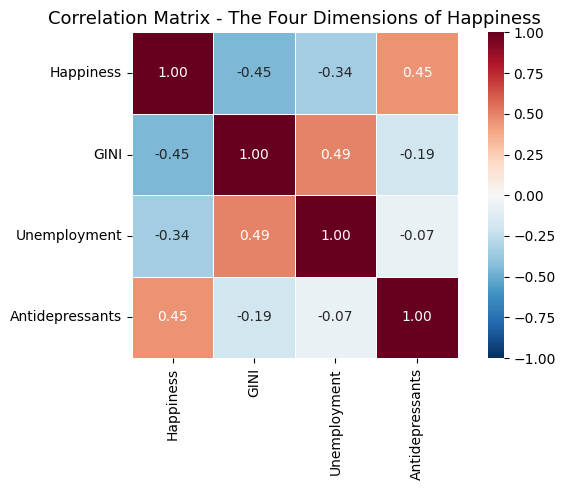

In [10]:
METRICS = ["Happiness", "GINI", "Unemployment", "Antidepressants"]

# Correlation matrix heatmap
corr = df[METRICS].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Correlation Matrix - The Four Dimensions of Happiness", fontsize=13)
plt.tight_layout()
os.makedirs("./docs/images", exist_ok=True)
fig.savefig("./docs/images/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Distribution of Each Metric

Histograms of 2015–2020 averages over 21 countries. Dashed line indicate the mean; dotted line the median. Ticks at the bottom mark individual country values.

**Happiness**: Roughly symmetric on each side of the scale, range 5.0–7.8. The mean (6.7) and median are close, with no extreme skew. Highlights how many countries are either on the happier side of the mean or on the less happy side and not many have average happiness. 

**GINI**: Roughly symmetric (range 23–49), with many small cluster of very equal countries.

**Unemployment**: Right-skewed, drive by some outliers with  high unemployment (11% and 17%). Many countries cluster between 4–8%.

**Antidepressants**: Fairly symmetric with a few outliers on the left and right. Between these specific outliers there is a nearly 8.75x range (Latvia ~16 → Iceland ~140 DDD). The Nordic countries tend to be on the right tail.

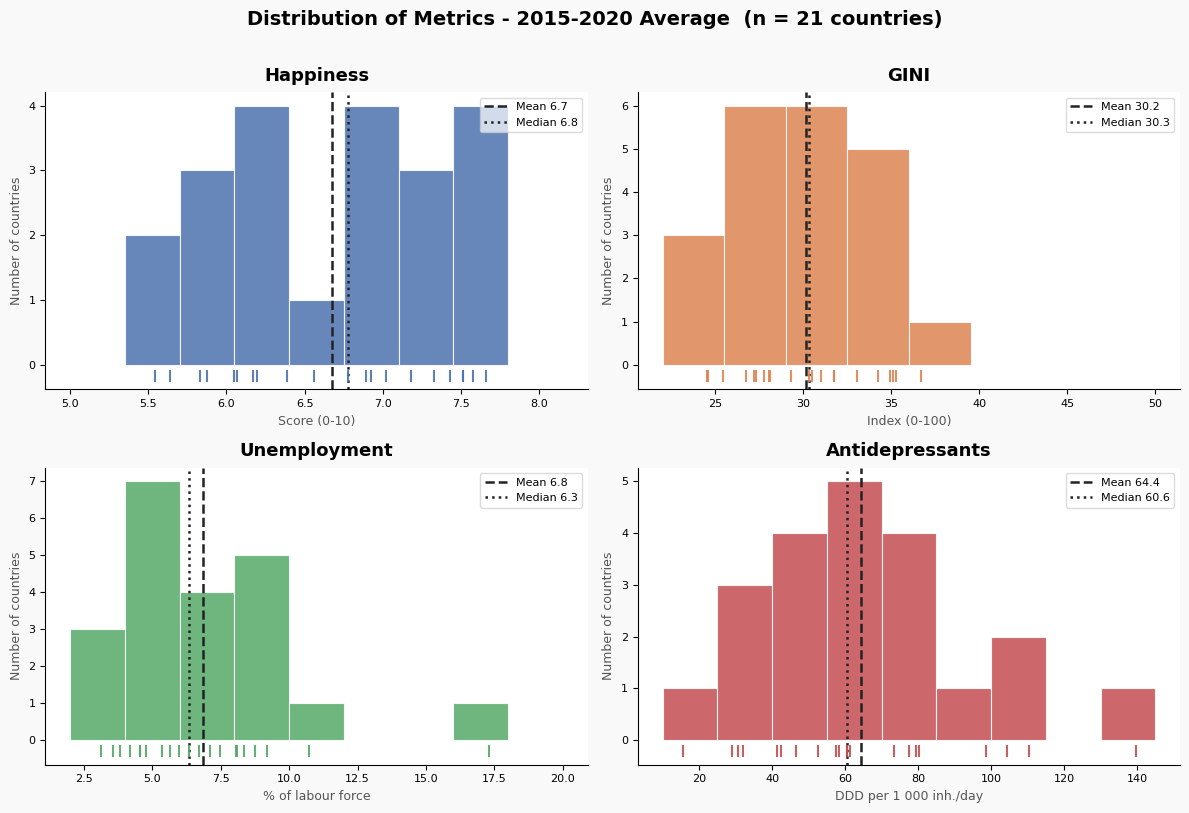

In [11]:
# Distribution histograms (2 × 2 grid)
METRIC_UNITS = ["Score (0-10)", "Index (0-100)", "% of labour force", "DDD per 1 000 inh./day"]
METRIC_BINS  = [
    np.arange(5.0,  8.3, 0.35),   # Happiness  (range ~2.4)
    np.arange(22,   52,  3.5),    # GINI       (range ~26)
    np.arange(2,    22,  2.0),    # Unemployment (range ~18)
    np.arange(10,  150, 15.0),    # Antidepressants (range ~124)
]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig_dist, axes_dist = plt.subplots(2, 2, figsize=(12, 8))
fig_dist.patch.set_facecolor("#f9f9f9")

for ax, col, color, unit, bins in zip(axes_dist.flat, METRICS, colors, METRIC_UNITS, METRIC_BINS):
    # Bars — no KDE / trend line
    ax.hist(df[col], bins=bins, color=color, edgecolor="white", linewidth=0.8, alpha=0.85)

    # Mean and median reference lines
    mean_val   = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val,   color="#222", linewidth=1.8, linestyle="--",
               label=f"Mean {mean_val:.1f}")
    ax.axvline(median_val, color="#222", linewidth=1.8, linestyle=":",
               label=f"Median {median_val:.1f}")

    # Rug ticks at the bottom showing individual country values
    ymax = ax.get_ylim()[1]
    ax.plot(df[col], np.full(len(df), -ymax * 0.04),
            "|", color=color, alpha=0.9, markersize=8, markeredgewidth=1.5,
            clip_on=False)

    ax.set_title(col, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel(unit, fontsize=9, color="#555")
    ax.set_ylabel("Number of countries", fontsize=9, color="#555")
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, framealpha=0.7, loc="upper right")

fig_dist.suptitle("Distribution of Metrics - 2015-2020 Average  (n = 21 countries)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig_dist.savefig("./docs/images/metric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### GINI vs. Happiness

This scatter confirms the negative linear relationship hinted at by the correlation matrix. Nordic countries cluster in the upper-left (low GINI ≈ 25–30, high happiness ≈ 7.0–7.8), while Southern and Eastern European countries tend toward the lower-right (higher GINI, lower happiness).

Notable observations:
- **France** is a relative outlier: fairly high inequality (GINI ≈ 31) for its moderate happiness score.
- **Slovenia** shows the reverse: low GINI (well-distributed income) but below-average happiness, suggesting equality alone is not sufficient for happiness.
- The negative trend is on the strong side.

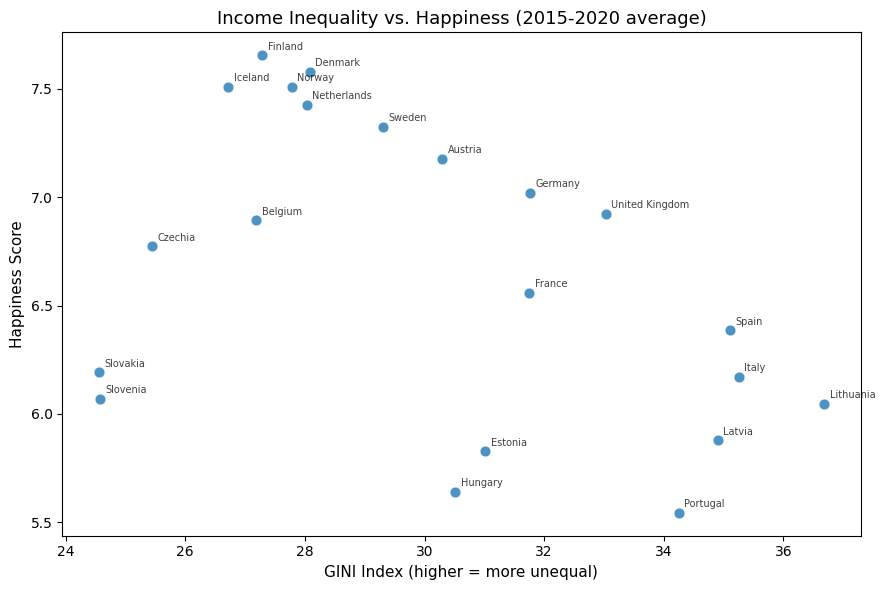

In [12]:
# Scatter plot of GINI vs Happiness
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df["GINI"], df["Happiness"], s=60, alpha=0.8, edgecolors="white", linewidth=0.5)

# Label each point with the country name
for _, row in df.iterrows():
    ax.annotate(
        row["Country"], (row["GINI"], row["Happiness"]),
        fontsize=7, alpha=0.75,
        xytext=(4, 4), textcoords="offset points",
    )

ax.set_xlabel("GINI Index (higher = more unequal)", fontsize=11)
ax.set_ylabel("Happiness Score", fontsize=11)
ax.set_title("Income Inequality vs. Happiness (2015-2020 average)", fontsize=13)
plt.tight_layout()
fig.savefig("./docs/images/gini_vs_happiness.png", dpi=150, bbox_inches="tight")
plt.show()

### Scatter Plot Matrix (Pairplot)

A 4 x 4 matrix of all pairwise scatter plots with OLS regression lines and $R^2$ values. Diagonal cells show kernel density estimates (KDE) of each variable.

**Summary of $R^2$ values:**
| Pair | R² | Direction |
|------|----|-----------|
| Happiness vs. GINI | 0.2 | Negative |
| Happiness vs. Unemployment | 0.12 | Negative |
| Happiness vs. Antidepressants | 0.20 | **Positive** (the paradox) |
| Antidepressants vs. GINI | 0.04 | None |
| Antidepressants vs. Unemployment | 0.0 | None |
| GINI vs. Unemployment | 0.24 | Positive |

The near-zero Antidepressants–GINI $R^2$ rules out a possible hypothesis that antidepressant use simply reflects poverty. The Happiness–Antidepressants positive slope ($R^2$ = 0.20) is moderate but consistent. Together, these patterns motivated us to proceed with a clustering analysis to see if there are distinct countries archetypes in the data.

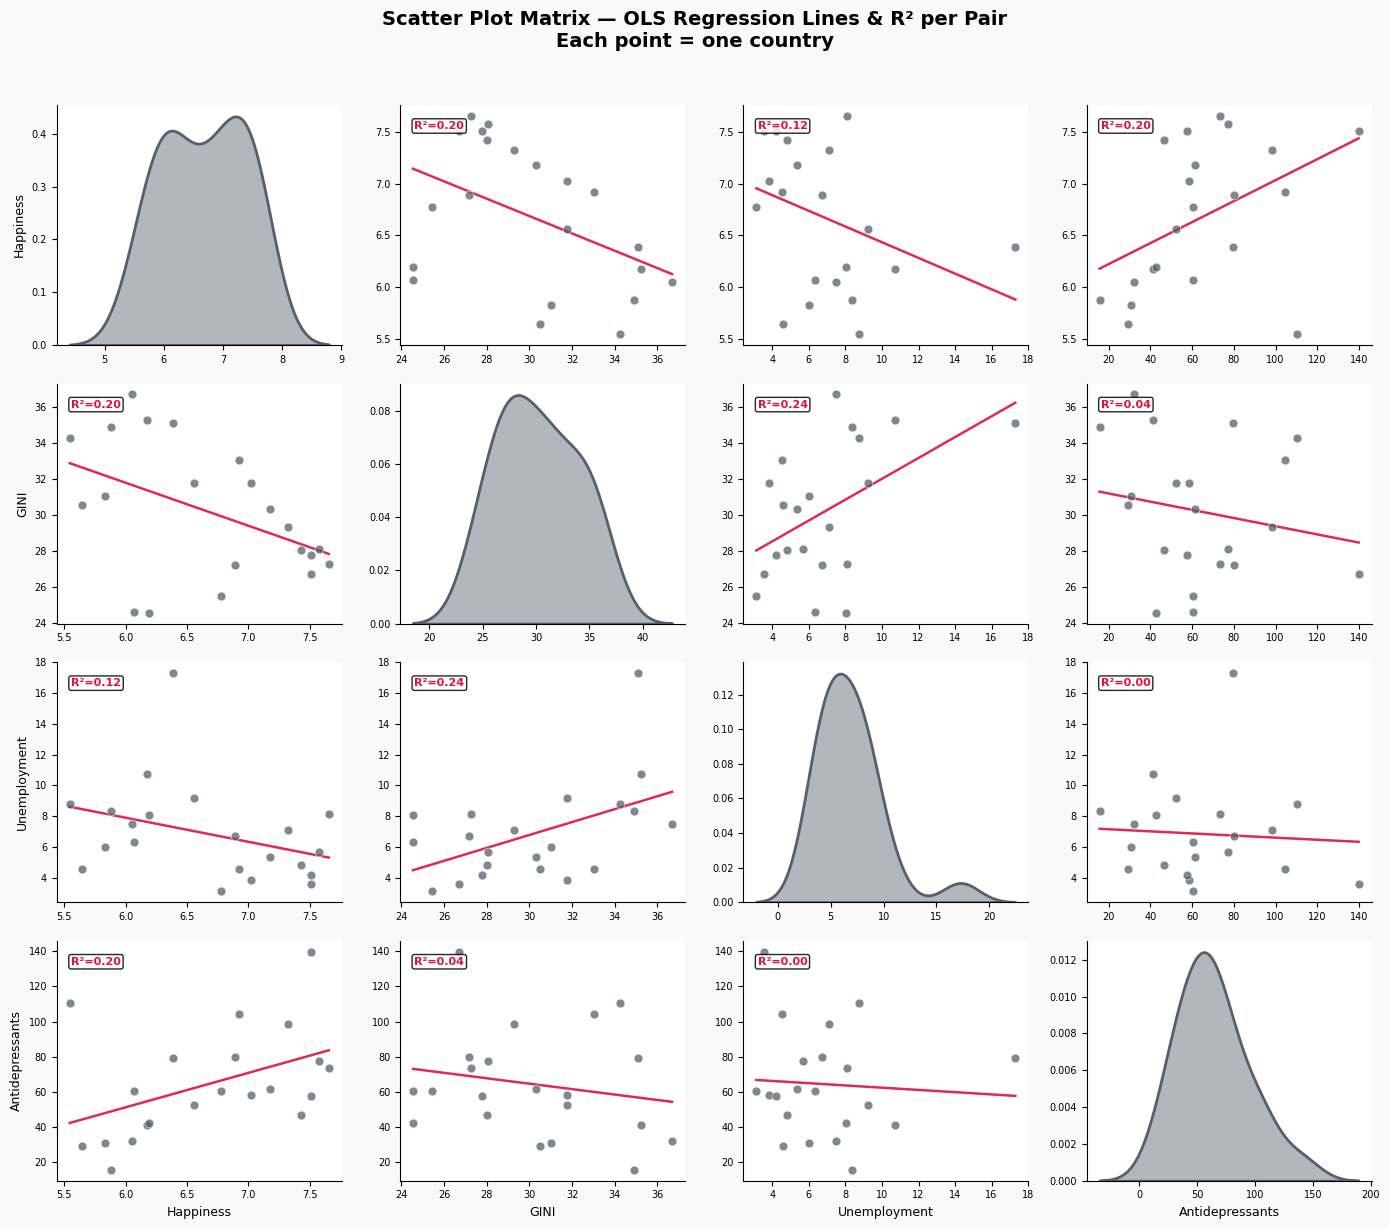

In [13]:
POINT_COLOR = "#555F6D"  # uniform neutral colour for all scatter points

n = len(METRICS)
fig_sm, axes_sm = plt.subplots(n, n, figsize=(14, 12))
fig_sm.patch.set_facecolor("#f9f9f9")

for i, row_m in enumerate(METRICS):
    for j, col_m in enumerate(METRICS):
        ax = axes_sm[i, j]
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)

        if i == j:
            # Diagonal: KDE coloured by this metric
            sns.kdeplot(df[row_m], ax=ax, color=POINT_COLOR,
                        fill=True, alpha=0.45, linewidth=2)
        else:
            x_vals = df[col_m].values
            y_vals = df[row_m].values

            # Uniform neutral colour for all points
            ax.scatter(x_vals, y_vals, c=POINT_COLOR,
                       alpha=0.75, s=40, edgecolors="white", linewidth=0.5,
                       zorder=3)

            # OLS regression line — solid crimson
            slope, intercept, r_val, p_val, _ = stats.linregress(x_vals, y_vals)
            x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
            ax.plot(x_line, slope * x_line + intercept,
                    color="crimson", linewidth=1.8, linestyle="-", alpha=0.9, zorder=2)

            # R² label — no significance stars
            ax.text(0.05, 0.90, f"R²={r_val**2:.2f}",
                    transform=ax.transAxes, fontsize=8, color="crimson",
                    fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85))

        # Axis labels on outer edges only
        ax.set_xlabel(col_m if i == n - 1 else "", fontsize=9)
        ax.set_ylabel(row_m if j == 0 else "", fontsize=9)
        ax.tick_params(labelsize=7)

fig_sm.suptitle(
    "Scatter Plot Matrix — OLS Regression Lines & R² per Pair\n"
    "Each point = one country",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
fig_sm.savefig("./docs/images/scatter_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Data Analysis — Machine Learning

## 3.1 Clustering: "Archetypes of Happiness"

We use **K-Means clustering** on the four standardised variables to discover natural groupings of countries. To find an appropriate value of $k$ we used the following measures:

| Diagnostic | What it measures |
|---|---|
| **Elbow plot** | Within-cluster inertia. Look for the "elbow" where the graphs flats out |
| **Silhouette analysis** | Average cohesion/separation per cluster (higher = better-separated) |

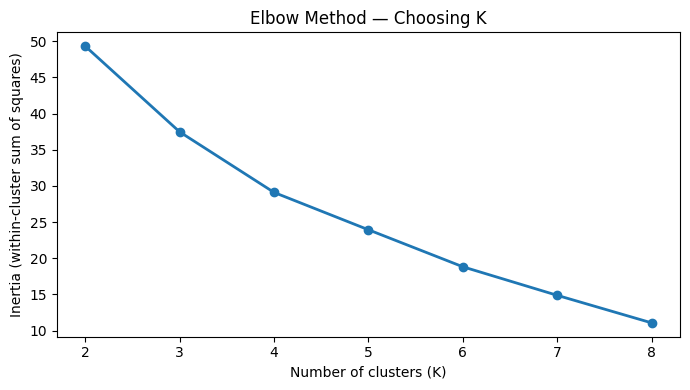

In [14]:
# Normalise features
scaler = StandardScaler()
X = df[METRICS].values
X_scaled = scaler.fit_transform(X)

# Elbow method: test K = 2..8
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig_pca, ax_pca = plt.subplots(figsize=(7, 4))
ax_pca.plot(K_range, inertias, "o-", linewidth=2)
ax_pca.set_xlabel("Number of clusters (K)")
ax_pca.set_ylabel("Inertia (within-cluster sum of squares)")
ax_pca.set_title("Elbow Method — Choosing K")
ax_pca.set_xticks(list(K_range))
plt.tight_layout()
fig_pca.savefig("./docs/images/elbow_method.png", dpi=150, bbox_inches="tight")
plt.show()

The elbow method plot in the figure above suggests that $k=3$ or $k=4$ is an appropriate value of $k$.

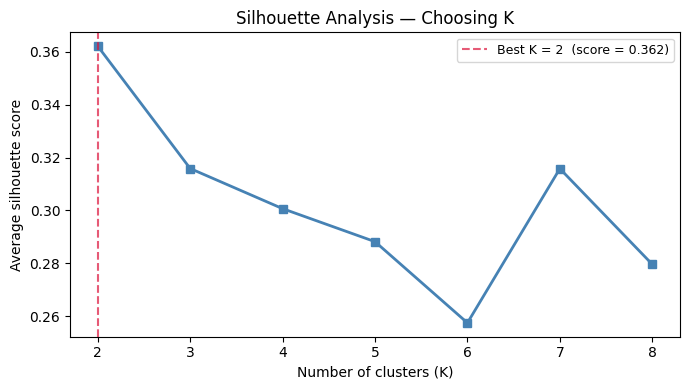

Silhouette scores by K:
  K=2  ->  0.3621 - best
  K=3  ->  0.3158
  K=4  ->  0.3006
  K=5  ->  0.2881
  K=6  ->  0.2574
  K=7  ->  0.3158
  K=8  ->  0.2796


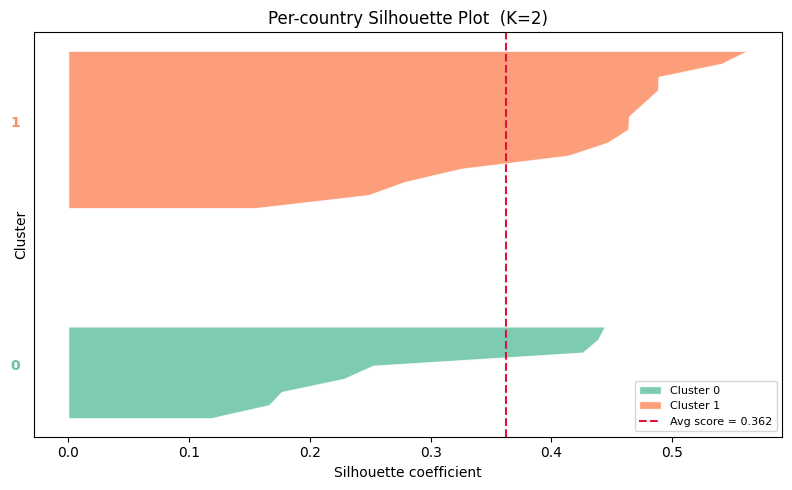

In [ ]:
# Silhouette analysis
sil_scores = []
for k in K_range:
    _km = KMeans(n_clusters=k, n_init=10, random_state=42)
    _labels = _km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, _labels))

fig_sil, ax_sil = plt.subplots(figsize=(7, 4))
ax_sil.plot(list(K_range), sil_scores, "s-", linewidth=2, color="steelblue")
ax_sil.set_xlabel("Number of clusters (K)")
ax_sil.set_ylabel("Average silhouette score")
ax_sil.set_title("Silhouette Analysis — Choosing K")
ax_sil.set_xticks(list(K_range))

best_k_sil = list(K_range)[int(np.argmax(sil_scores))]
ax_sil.axvline(best_k_sil, color="crimson", linestyle="--", alpha=0.7,
               label=f"Best K = {best_k_sil}  (score = {max(sil_scores):.3f})")
ax_sil.legend(fontsize=9)
plt.tight_layout()
fig_sil.savefig("./docs/images/silhouette_scores.png", dpi=150, bbox_inches="tight")
plt.show()

print("Silhouette scores by K:")
for k, s in zip(K_range, sil_scores):
    marker = " - best" if k == best_k_sil else ""
    print(f"  K={k}  ->  {s:.4f}{marker}")

From the silhouette analysis and the two plots we can observe how $k=2$ has the highest score, followed by $k=3$ in the second position. We use these results from this analysis to motivate our choice of $k$ below.


**Why we will use $k$ = 3 instead of $k$ = 2?**  
Even thought $k$ = 2 yields the highest silhouette score, it collapses the dataset into a "happy North vs. unhappy South" split that hides the within-group variation. $k$ = 3 provides a more interpretable structure a "Nordic high-happiness / high-medication" cluster, a "Continental moderate" cluster, and a "Southern / Eastern lower-happiness" cluster (see summary table below to read the list of countries in each cluster). All of this while maintaining a high silhouette score (≈ 0.315) with no singleton clusters (cluster represented only by 1 country). This trade-off motivated our the final choice.

### 3D plot for interactive visualization of the clusters

In [16]:
# Fit K-Means with chosen K
# K=3 chosen via silhouette analysis (best trade-off: no singletons, score=0.316)
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=42)
df["Cluster"] = km.fit_predict(X_scaled)

# ── PCA to 3 dimensions for interactive 3D visualisation ─────
pca = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(X_scaled)
df["PC1"] = coords[:, 0]
df["PC2"] = coords[:, 1]
df["PC3"] = coords[:, 2]

total_var = sum(pca.explained_variance_ratio_[:3])
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"PC3={pca.explained_variance_ratio_[2]:.1%}, "
      f"Total={total_var:.1%}")

# 3D Interactive cluster plot (Plotly)
cluster_colors_pca = ["#66c2a5", "#fc8d62", "#8da0cb"]
fig_pca3d = go.Figure()

for cid in range(K):
    mask = df["Cluster"] == cid
    sub = df[mask]
    fig_pca3d.add_trace(go.Scatter3d(
        x=sub["PC1"], y=sub["PC2"], z=sub["PC3"],
        mode="markers+text",
        text=sub["Country"],
        textposition="top center",
        textfont=dict(size=7),
        marker=dict(size=6, color=cluster_colors_pca[cid], opacity=0.85,
                    line=dict(width=0.5, color="white")),
        name=f"Cluster {cid} ({mask.sum()})",
        hovertemplate="<b>%{text}</b><br>PC1=%{x:.2f}<br>PC2=%{y:.2f}<br>PC3=%{z:.2f}<extra></extra>",
    ))

fig_pca3d.update_layout(
    title=dict(
        text="K-Means Clusters in 3D PCA Space<br>"
             f"<sup>Total variance captured: {total_var:.0%} · Drag to rotate</sup>",
        x=0.5,
    ),
    scene=dict(
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})",
        zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]:.0%})",
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
    ),
    height=520,
    template="plotly_white",
    margin=dict(t=80, b=30, l=20, r=20),
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.02,
                font=dict(size=10)),
)

fig_pca3d.write_html("./docs/visualizations/pca_clusters_3d.html",
                     include_plotlyjs="cdn", config={"responsive": True})
fig_pca3d.show()

PCA explained variance: PC1=50.6%, PC2=25.7%, PC3=12.3%, Total=88.6%


In the plot we show the 3 clusters in a 3 dimensional space. **PCA** was used to reduce the feature space for the interactive visualization. The three principal components together explain 88.6% of the total variance in the data making the plot a good indicator of the actual separation between the clusters.


In [17]:
# Cluster summary table
cluster_summary = df.groupby("Cluster")[METRICS].mean().round(2)
cluster_summary["Count"] = df.groupby("Cluster")["Country"].count().values
display(cluster_summary)

# Countries per cluster
print("\n=== Countries per Cluster ===")
for cid in sorted(df["Cluster"].unique()):
    countries = sorted(df[df["Cluster"] == cid]["Country"].tolist())
    print(f"\nCluster {cid} ({len(countries)} countries): {', '.join(countries)}")

,Happiness,GINI,Unemployment,Antidepressants,Count
Cluster,,,,,
0,7.25,28.63,5.18,78.04,11
1,6.10,34.66,10.31,55.24,6
2,5.93,27.66,6.24,40.74,4



=== Countries per Cluster ===

Cluster 0 (11 countries): Austria, Belgium, Czechia, Denmark, Finland, Germany, Iceland, Netherlands, Norway, Sweden, United Kingdom

Cluster 1 (6 countries): France, Italy, Latvia, Lithuania, Portugal, Spain

Cluster 2 (4 countries): Estonia, Hungary, Slovakia, Slovenia


Summary table presenting the average values of: Happiness, GINI, Unemployment rate and Antidepressants usage in the three clusters. Additionally a list of countries belonging to each cluster is presented.

## 3.2 Temporal Interactive Visualizations

Instead of only looking at 5-year averages, we now look at the data **year-by-year** (2015–2020) to check whether the paradox patterns are stable over time or driven by a single outlier year.

Four complementary interactive charts are produced, each telling a different aspect of the story:
1. **Animated scatter** — does the antidepressant–happiness correlation persist each year?
2. **Bump chart** — did the ranking of countries change dramatically?
3. **Geographic view** — geographic clustering of the paradox.
4. **Folium map** — did the things actually got better or worse over the years?

In [18]:
# Build year-level dataset for the retained European countries
retained = set(df["Country"].tolist())
cluster_map = df.set_index("Country")["Cluster"].to_dict()

# If df_temporal was loaded from pre-cleaned CSV, use it directly;
# otherwise reconstruct from the individual preprocessing dataframes.
if 'df_temporal' in dir() and df_temporal is not None:
    df_t = df_temporal[df_temporal["Country"].isin(retained)].copy()
    df_t["Cluster"] = df_t["Country"].map(cluster_map).astype(int)
    df_t["Cluster_label"] = "Cluster " + df_t["Cluster"].astype(str)
    df_t = df_t.sort_values(["Country", "Year"]).reset_index(drop=True)
else:
    t_hap  = df_hap[df_hap["Country_std"].isin(retained)][["Country_std","Year","Happiness"]].copy()
    t_gini = df_gini[df_gini["Country_std"].isin(retained)][["Country_std","Year","GINI"]].copy()
    t_unem = df_unem[df_unem["Country_std"].isin(retained)][["Country_std","Year","Unemployment"]].copy()
    t_anti = df_anti[df_anti["Country_std"].isin(retained)][["Country_std","Year","Antidepressants"]].copy()

    # Outer merge, keeps all year entries even if some metrics have gaps
    df_t = (
        t_hap
        .merge(t_gini, on=["Country_std","Year"], how="outer")
        .merge(t_unem, on=["Country_std","Year"], how="outer")
        .merge(t_anti, on=["Country_std","Year"], how="outer")
    )
    df_t.rename(columns={"Country_std": "Country"}, inplace=True)
    df_t["Cluster"]       = df_t["Country"].map(cluster_map).astype(int)
    df_t["Cluster_label"] = "Cluster " + df_t["Cluster"].astype(str)
    df_t = df_t.sort_values(["Country","Year"]).reset_index(drop=True)

# Complete-cases subset (all 4 metrics present) for animated charts
df_tc = df_t.dropna(subset=["Happiness","GINI","Unemployment","Antidepressants"]).copy()

print(f"Full temporal  : {len(df_t)} rows | {df_t['Country'].nunique()} countries")
print(f"Complete cases : {len(df_tc)} rows")
print(f"Years covered  : {sorted(df_t['Year'].unique())}")


Full temporal  : 126 rows | 21 countries
Complete cases : 126 rows
Years covered  : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


### Chart 1 — Animated Scatter: Does the Paradox Persist Each Year?

Each frame is a single year. If the positive antidepressant–happiness relationship is visible in every frame, the paradox is structural rather than an averaging artefact.

In [19]:
# Animated scatter: Happiness vs Antidepressants, year by year
# Bubble size = Unemployment  ·  Colour = cluster  ·  Text = country name

fig_anim = px.scatter(
    df_tc.sort_values("Year"),
    x="Antidepressants",
    y="Happiness",
    animation_frame="Year",
    animation_group="Country",
    size="Unemployment",
    color="Cluster_label",
    text="Country",                # country name shown on each bubble
    hover_name="Country",
    hover_data={
        "GINI": ":.1f",
        "Unemployment": ":.1f",
        "Antidepressants": ":.1f",
        "Cluster_label": False,
        "Year": False,
    },
    color_discrete_sequence=cluster_colors[:K],
    size_max=35,
    title=(
        "Does the Paradox Persist? Antidepressant Use vs Happiness (2015–2020)<br>"
        "<sup>Bubble size = Unemployment rate  ·  Press ▶ to animate through years</sup>"
    ),
    labels={
        "Antidepressants": "Antidepressants (DDD per 1 000 inh./day)",
        "Happiness": "Happiness Score",
        "Cluster_label": "Cluster",
    },
    template="plotly_white",
    height=640,
)

# Show text labels on all frames
fig_anim.update_traces(textposition="top center", textfont_size=8, mode="markers+text")

# Fix axis ranges so bubbles don't jump around between frames
fig_anim.update_layout(
    title_x=0.5,
    xaxis=dict(range=[df_tc["Antidepressants"].min() - 5, df_tc["Antidepressants"].max() + 5]),
    yaxis=dict(range=[df_tc["Happiness"].min() - 0.3,     df_tc["Happiness"].max() + 0.3]),
    # Horizontal legend just below the subtitle, above the plot
    legend=dict(
        title_text="Cluster",
        orientation="h",
        x=0.5, xanchor="center",
        y=1.06, yanchor="bottom",
        font=dict(size=9),
    ),
    margin=dict(t=130, b=60),
)

fig_anim.show()
fig_anim.write_html("./docs/visualizations/happiness_animated.html", include_plotlyjs="cdn",
                    config={"responsive": True})
print("Saved → ./docs/visualizations/happiness_animated.html")

Saved → ./docs/visualizations/happiness_animated.html


This interactive plot shows how the Antidepressants usage and Happiness score evolved over the 5 years range. The color highlight the cluster of belonging, the bubble size is the unemployment rate. From the animation we can see three separate trends. The first one is a slight increase in happiness over all the considered countries, the second one is an overall shift to the right (indicating higher usage of antidepressants), and finally the third trend is a slight decrease in unemployment rate (the size of the bubbles tend to decrease). It's noticeable the evolution of Portugal as it becomes, over the years, an outlier to the paradox. It in facts ends up as the second overall for consumption of antidepressants but with one of the lowest happiness score overall. All other counties tend to stay in their area maintaining more or less the same distances to the neighboring points. 

### Chart 2 — Bump Chart: Happiness Rankings Over Time

In [20]:
# Rank within the retained European countries each year (1 = happiest)
df_rank = df_t[df_t["Happiness"].notna()].copy()
df_rank["Rank"] = (
    df_rank.groupby("Year")["Happiness"]
    .rank(ascending=False, method="min")
    .astype(int)
)

years            = sorted(df_rank["Year"].unique())
countries_list   = sorted(df_rank["Country"].unique())
country_cluster  = df_rank.groupby("Country")["Cluster"].first().to_dict()
cluster_legend_added = set()

fig_bump = go.Figure()

# Initial traces: show only the first year
for country in countries_list:
    cid        = country_cluster[country]
    cdata_full = df_rank[df_rank["Country"] == country].sort_values("Year")
    cdata_y0   = cdata_full[cdata_full["Year"] == years[0]]

    show_legend = cid not in cluster_legend_added
    if show_legend:
        cluster_legend_added.add(cid)

    x0 = cdata_y0["Year"].tolist()
    y0 = cdata_y0["Rank"].tolist()

    fig_bump.add_trace(go.Scatter(
        x=x0,
        y=y0,
        mode="lines+markers+text",
        name=f"Cluster {cid}",
        legendgroup=f"Cluster {cid}",
        showlegend=show_legend,
        line=dict(color=cluster_colors[cid], width=2.5),
        marker=dict(size=8, color=cluster_colors[cid], symbol="circle"),
        text=[country] if x0 else [],
        textposition="middle right",
        textfont=dict(size=8, color="#333"),
        hovertemplate=(
            f"<b>{country}</b><br>"
            "Year: %{x}<br>Rank: %{y}<extra></extra>"
        ),
    ))

# Frames: progressively reveal each year
frames = []
for yr in years:
    frame_data = []
    for country in countries_list:
        cdata      = df_rank[df_rank["Country"] == country].sort_values("Year")
        cdata_upto = cdata[cdata["Year"] <= yr]

        x_vals = cdata_upto["Year"].tolist()
        y_vals = cdata_upto["Rank"].tolist()
        # Country name shown only at the rightmost visible point
        text_labels = [""] * len(x_vals)
        if text_labels:
            text_labels[-1] = country

        frame_data.append(go.Scatter(x=x_vals, y=y_vals, text=text_labels))

    frames.append(go.Frame(data=frame_data, name=str(yr)))

fig_bump.frames = frames

fig_bump.update_layout(
    title=dict(
        text=(
            "Happiness Rankings 2015–2020 — Bump Chart<br>"
            "<sup>Rank 1 = happiest  ·  Press ▶ to animate through years</sup>"
        ),
        x=0.5,
    ),
    xaxis=dict(title="Year", tickvals=years, range=[years[0] - 0.3, years[-1] + 1.3]),
    yaxis=dict(
        title="Rank (1 = happiest)",
        autorange="reversed",
        dtick=1,
        gridcolor="#e8e8e8",
        tickfont=dict(size=10),
    ),
    template="plotly_white",
    height=850,
    legend=dict(
        orientation="h",
        x=0.5, xanchor="center",
        y=1.0, yanchor="bottom",
        title_text="Cluster",
        font=dict(size=9),
        tracegroupgap=5,
    ),
    margin=dict(r=50, t=100, b=80),
    updatemenus=[dict(
        type="buttons",
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[None, dict(
                    frame=dict(duration=700, redraw=False),
                    transition=dict(duration=400, easing="cubic-in-out"),
                )],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[[None], dict(
                    frame=dict(duration=0, redraw=False),
                    mode="immediate",
                    transition=dict(duration=0),
                )],
            ),
        ],
        direction="left",
        pad=dict(r=10, t=5),
        showactive=False,
        x=0.0, xanchor="left",
        y=-0.08, yanchor="top",
    )],
    # Year slider
    sliders=[dict(
        active=0,
        steps=[dict(
            method="animate",
            args=[[str(yr)], dict(
                mode="immediate",
                frame=dict(duration=600, redraw=False),
                transition=dict(duration=400, easing="cubic-in-out"),
            )],
            label=str(yr),
        ) for yr in years],
        x=0.15, len=0.75,
        y=-0.06,
        currentvalue=dict(prefix="Year: ", visible=True, xanchor="center", font=dict(size=11)),
        transition=dict(duration=400),
        font=dict(size=10),
    )],
)

fig_bump.show()
fig_bump.write_html("./docs/visualizations/happiness_bump.html", include_plotlyjs="cdn",
                    config={"responsive": True})
print("Saved → ./docs/visualizations/happiness_bump.html")

Saved → ./docs/visualizations/happiness_bump.html


A bump chart shows *relative* position. Countries whose rank is stable across 5 years confirm that the cluster structure is persistent. We see how the top spots are dominated by Scandinavian countries plus the Netherlands while in the bottom half of the ranking there are southern European and eastern European countries. 

### Chart 3 — Geographic View: Plotly Choropleth

Does the paradox cluster geographically? Toggle between the happiness map and the antidepressant map to see if the same countries light up.

In [21]:
# Get ISO alpha-3 codes (needed by Plotly choropleth)
def get_iso3(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

df_map = df[["Country","Happiness","Antidepressants","GINI","Unemployment","Cluster"]].copy()
df_map["ISO_A3"] = df_map["Country"].apply(get_iso3)
df_map.dropna(subset=["ISO_A3"], inplace=True)

# Two traces — one per metric — toggled via buttons
fig_geo = go.Figure()

fig_geo.add_trace(go.Choropleth(
    locations=df_map["ISO_A3"],
    z=df_map["Happiness"],
    text=df_map["Country"],
    hovertemplate="<b>%{text}</b><br>Happiness: %{z:.2f}<extra></extra>",
    colorscale="YlGn",
    zmin=5, zmax=8,
    colorbar=dict(title="Score", x=1.02),
    visible=True,
    name="Happiness",
))

fig_geo.add_trace(go.Choropleth(
    locations=df_map["ISO_A3"],
    z=df_map["Antidepressants"],
    text=df_map["Country"],
    hovertemplate="<b>%{text}</b><br>Antidepressants: %{z:.1f} DDD per 1 000 inh./day<extra></extra>",
    colorscale="OrRd",
    colorbar=dict(title="DDD per 1 000<br>inh./day", x=1.02),
    visible=False,
    name="Antidepressants",
))

fig_geo.update_layout(
    title=dict(
        text=(
            "The Paradox Visualised Geographically<br>"
            "<sup>Toggle to see if the same countries score high on both maps</sup>"
        ),
        x=0.5,
        y=0.97,
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        showcountries=True,
        fitbounds="locations",
    ),
    updatemenus=[dict(
        type="buttons",
        direction="right",
        x=0.5, xanchor="center",
        y=1.09, yanchor="top",      # positioned at the top
        pad=dict(r=5, t=4, b=4, l=5),
        font=dict(size=11),          # smaller button text
        buttons=[
            dict(
                label="Happiness Score",
                method="update",
                args=[{"visible": [True, False]}],
            ),
            dict(
                label="Antidepressant Use",
                method="update",
                args=[{"visible": [False, True]}],
            ),
        ],
        showactive=True,
        bgcolor="white",
        bordercolor="#aaa",
        borderwidth=1,
    )],
    height=560,
    template="plotly_white",
    margin=dict(t=105, r=20, l=20),
)

fig_geo.show()
fig_geo.write_html("./docs/visualizations/happiness_geo.html", include_plotlyjs="cdn",
                   config={"responsive": True})
print("Saved → ./docs/visualizations/happiness_geo.html")


Saved → ./docs/visualizations/happiness_geo.html


This interactive plot gives the reader a quick way to compare Happiness and Antidepressant use in a visual way across Europe. As already mentioned the Scandinavian countries tend to correlated more between the two tabs while Portugal can be seen as a clear outlier of the correlation phenomenon.  

### Chart 4 — Who Got Happier? Folium Map of Happiness 

In contrast with the above map, this map asks: **did things actually improve over time?**. Let's see:

In [22]:
# -- Compute happiness change 2015 -> 2020
hap_2015 = (
    df_t[df_t['Year'] == 2015][['Country', 'Happiness']]
    .dropna().set_index('Country')['Happiness']
)
hap_2020 = (
    df_t[df_t['Year'] == 2020][['Country', 'Happiness']]
    .dropna().set_index('Country')['Happiness']
)
common   = hap_2015.index.intersection(hap_2020.index)
df_delta = pd.DataFrame({
    'Country':        common,
    'Happiness_2015': hap_2015[common].values,
    'Happiness_2020': hap_2020[common].values,
    'Delta':          (hap_2020[common] - hap_2015[common]).values,
})

# Approximate lat/lon for the retained European countries
CHANGE_COORDS = {
    'Austria':                 ( 47.5,   14.6),
    'Belgium':                 ( 50.5,    4.5),
    'Czechia':                 ( 49.8,   15.5),
    'Denmark':                 ( 56.3,    9.5),
    'Estonia':                 ( 58.6,   25.0),
    'Finland':                 ( 61.9,   25.7),
    'France':                  ( 46.2,    2.2),
    'Germany':                 ( 51.2,   10.5),
    'Hungary':                 ( 47.2,   19.5),
    'Iceland':                 ( 64.9,  -19.0),
    'Italy':                   ( 41.9,   12.6),
    'Latvia':                  ( 56.9,   24.6),
    'Lithuania':               ( 55.2,   23.9),
    'Netherlands':             ( 52.3,    5.3),
    'Norway':                  ( 60.5,    8.5),
    'Portugal':                ( 39.4,   -8.2),
    'Slovakia':                ( 48.7,   19.7),
    'Slovenia':                ( 46.2,   15.0),
    'Spain':                   ( 40.5,   -3.7),
    'Sweden':                  ( 60.1,   18.6),
    'United Kingdom':          ( 55.4,   -3.4),
}

max_abs = df_delta['Delta'].abs().max()
m_change = folium.Map(location=[54, 10], zoom_start=4, tiles='CartoDB positron')

for _, row in df_delta.iterrows():
    coords = CHANGE_COORDS.get(row['Country'])
    if coords is None:
        continue
    delta  = row['Delta']
    color  = '#27AE60' if delta >= 0 else '#E74C3C'
    radius = max(6, abs(delta) / max_abs * 28)
    sign   = '+' if delta >= 0 else ''
    popup_html = (
        f"<b style='font-size:13px'>{row['Country']}</b><br>"
        f"2015: {row['Happiness_2015']:.2f}<br>"
        f"2020: {row['Happiness_2020']:.2f}<br>"
        f"<span style='color:{color};font-weight:bold'>Change: {sign}{delta:.2f}</span>"
    )
    folium.CircleMarker(
        location=coords,
        radius=radius,
        color='white', weight=1.5,
        fill=True, fill_color=color, fill_opacity=0.88,
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=f"{row['Country']}: {sign}{delta:.2f}",
    ).add_to(m_change)

legend_html = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:9999;'
    'background:white;padding:12px 16px;border-radius:8px;'
    'border:1px solid #ccc;font-family:sans-serif;font-size:12px;">'
    '<b>Happiness Change 2015&#8594;2020</b><br>'
    '<span style="color:#27AE60;font-size:16px;">&#9679;</span> Increased &nbsp;'
    '<span style="color:#E74C3C;font-size:16px;">&#9679;</span> Decreased<br>'
    '<span style="color:#888">Circle size = magnitude of change</span></div>'
)
m_change.get_root().html.add_child(folium.Element(legend_html))

import os; os.makedirs('./docs/visualizations', exist_ok=True)
change_path = './docs/visualizations/happiness_change_map.html'
m_change.save(change_path)
print(f'Saved -> {change_path}')
m_change


Saved -> ./docs/visualizations/happiness_change_map.html


Each circle represents one country and it's evolution of the happiness value: **green** if happiness rose, **red** if it fell. Circle size reflects the magnitude of change. When clicked on a marker, full details are showed. The overall happiness across Europe increased with only minimal drops in Belgium and Norway. 

### Other Enhanced Visualizations

The three charts below deepen the analysis by bringing in the **European Social Survey (ESS Round 9)** data. These charts investigate which countries have higher institutional trust and social connectedness and how this correlates to Happiness and Antidepressants use.

#### Chart 5 — Institutional Trust vs. Happiness (ESS scatter)

In [26]:
# ESS Institutional Trust vs Happiness Scatter
# OLS regression
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Institutional_Trust'], df['Happiness'])
r2 = r_value**2

fig = go.Figure()

for cid in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cid
    sub = df[mask]
    fig.add_trace(go.Scatter(
        x=sub['Institutional_Trust'],
        y=sub['Happiness'],
        mode='markers+text',
        text=sub['Country'],
        textposition='top center',
        textfont=dict(size=8),
        marker=dict(
            size=sub['Antidepressants'] / 4,
            color=cluster_colors[cid],
            opacity=0.75,
            line=dict(width=1, color='white'),
            sizemin=5,
        ),
        name=f'Cluster {cid}',
        showlegend=False,
        hovertemplate=(
            '<b>%{text}</b><br>'
            'Inst. Trust: %{x:.2f}<br>'
            'Happiness: %{y:.2f}<extra></extra>'
        ),
    ))

# Add OLS trend line
x_range = [df['Institutional_Trust'].min() - 0.1, df['Institutional_Trust'].max() + 0.1]
fig.add_trace(go.Scatter(
    x=x_range, y=[slope * x + intercept for x in x_range],
    mode='lines', line=dict(color='rgba(0,0,0,0.4)', dash='dash', width=2),
    showlegend=False, name='OLS'
))

fig.update_layout(
    title=dict(
        text=f"The Trust Explanation: Institutional Trust vs Happiness<br><sup>R² = {r2:.3f}, p = {p_value:.2e} | Bubble size = Antidepressant consumption (DDD per 1 000 inh./day)</sup>",
        x=0.5,
    ),
    xaxis_title='Institutional Trust (z-score composite)',
    yaxis_title='Happiness Score (0-10)',
    height=600,
    template='plotly_white',
    showlegend=False,
)

fig.write_html("./docs/visualizations/ess_trust_vs_happiness.html", include_plotlyjs='cdn',
               config={"responsive": True})
print(f"Saved → ./docs/visualizations/ess_trust_vs_happiness.html (R² = {r2:.3f}, p = {p_value:.2e})")
fig.show()


Saved → ./docs/visualizations/ess_trust_vs_happiness.html (R² = 0.749, p = 4.01e-07)



This scatter tests the hypothesis that **trust in institutions** is the primary driver of cross-country happiness differences. Institutional Trust (z-score composite of trust in people, trust in politicians, and satisfaction with democracy) on the x-axis vs. Happiness Score on the y-axis. The size of the bubble represents the antidepressant consumption. It can be seen how the OLS regression line, $R^2$, and p-value show that well institutional trust alone predicts happiness. A strong fit, like this case, means that once you know how much a country's citizens trust their institutions, you can predict its happiness. The bubble size shows that it's not so obvious that countries with higher level or happiness and trust have always higher levels of antidepressant consumption. We can see a trend with Iceland, Finland, Sweden, and Denmark, but not for example for Norway compare to the levels of France, Spain and Portugal.

#### Chart 6 — Social Fabric Profiles: ESS Cluster Radar Chart

A **radar chart** showing how the three clusters differ across the six raw ESS variables. We normalized all variables to range to 0–1 so all axes are comparable.

In [ ]:
# ESS Cluster Radar Chart
# One trace per cluster; 6 axes = raw ESS variables, min-max normalised 0–1

ess_raw_vars = ['inprdsc', 'ppltrst', 'trstplt', 'stfdem', 'sclmeet', 'sclact']
ess_labels = ['Discuss Politics', 'Trust in People', 'Trust in Politicians',
              'Satisfaction w/ Democracy', 'Social Meetings', 'Social Activities']

# Min-max normalise across all 21 countries
df_norm = df[ess_raw_vars].copy()
for col in ess_raw_vars:
    mn, mx = df_norm[col].min(), df_norm[col].max()
    df_norm[col] = (df_norm[col] - mn) / (mx - mn)

df_norm['Cluster'] = df['Cluster']

# Cluster means
cluster_means = df_norm.groupby('Cluster')[ess_raw_vars].mean()

fig = go.Figure()

for cluster_id in sorted(cluster_means.index):
    values = cluster_means.loc[cluster_id].tolist()
    values += [values[0]]  # close the polygon
    n_countries = (df['Cluster'] == cluster_id).sum()
    countries = ', '.join(df.loc[df['Cluster'] == cluster_id, 'Country'].tolist())

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=ess_labels + [ess_labels[0]],
        fill='toself',
        name=f"Cluster {cluster_id} ({n_countries})",
        line_color=cluster_colors[cluster_id],
        opacity=0.6,
        hovertemplate=f"Cluster {cluster_id}<br>{countries}<br>%{{theta}}: %{{r:.2f}}<extra></extra>"
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=dict(
        text="Social Fabric Profiles: ESS Variables by Cluster<br><sup>Min-max normalised (0 = lowest in dataset, 1 = highest)</sup>",
        x=0.5,
    ),
    height=600,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=-0.2, xanchor='center', x=0.5)
)

fig.write_html("./docs/visualizations/ess_cluster_radar.html", include_plotlyjs='cdn',
               config={"responsive": True})
print("Saved → ./docs/visualizations/ess_cluster_radar.html")
fig.show()


Saved → ./docs/visualizations/ess_cluster_radar.html


Each polygon represents one cluster's average profile. We can see how cluster 0 (Nordic/high-happiness) dominates *every* axis simultaneously, higher trust in people, higher trust in politicians, higher democratic satisfaction, and more social engagement. Cluster 1 (Continental/Southern) and cluster 2 (Eastern) each have a distinct profile, cluster 1 has a high spike in social meetings and activities while cluster 2 is more balanced than 1 but with little to no satisfaction with democracy.

#### Chart 7 — Enhanced Bubble Chart: Explore the Paradox (Swappable X-Axis)

This is the **reader-exploration** phase of the Martini Glass structure. The bubble chart defaults to Institutional Trust on the x-axis and Happiness on the y-axis, with **bubble size encoding antidepressant consumption** and color encoding representing the 3 different clusters.

In [ ]:
# Enhanced Bubble Chart with ESS Dropdown Axes
# Overwrites the existing bubble chart with additional ESS axis options

x_options_enhanced = {
    "Unemployment Rate (%)": df["Unemployment"].values,
    "GINI Index": df["GINI"].values,
    "Institutional Trust (z-composite)": df["Institutional_Trust"].values,
    "Social Connection (z-composite)": df["Social_Connection"].values,
    "Trust in People (0-10)": df["ppltrst"].values,
    "Satisfaction w/ Democracy (0-10)": df["stfdem"].values,
}

fig = go.Figure()

default_x = "Institutional Trust (z-composite)"

for cid in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cid
    sub = df[mask]
    hover = [
        f"<b>{row['Country']}</b><br>"
        f"Happiness: {row['Happiness']:.2f}<br>"
        f"Inst. Trust: {row['Institutional_Trust']:.2f}<br>"
        f"Social Conn.: {row['Social_Connection']:.2f}<br>"
        f"Antidepressants: {row['Antidepressants']:.1f} DDD per 1 000 inh./day"
        for _, row in sub.iterrows()
    ]
    fig.add_trace(go.Scatter(
        x=sub["Institutional_Trust"],
        y=sub["Happiness"],
        mode="markers+text",
        text=sub["Country"],
        textposition="top center",
        textfont=dict(size=8),
        marker=dict(
            size=sub["Antidepressants"] / 4,
            color=cluster_colors[cid],
            opacity=0.75,
            line=dict(width=1, color="white"),
            sizemin=5,
        ),
        name=f"Cluster {cid}",
        hovertext=hover,
        hoverinfo="text",
    ))

# Dropdown buttons
buttons = []
for label, x_values in x_options_enhanced.items():
    x_per_trace = []
    for cid in sorted(df["Cluster"].unique()):
        mask = df["Cluster"] == cid
        x_per_trace.append(x_values[mask.values])
    buttons.append(dict(
        label=label,
        method="update",
        args=[{"x": x_per_trace}, {"xaxis.title.text": label}],
    ))

fig.update_layout(
    title=dict(
        text="Explore the Paradox: Swap X-Axis Freely<br>"
             "<sup>Bubble size = Antidepressant consumption (DDD per 1 000 inh./day)   "
             "Colour = K-Means cluster</sup>",
        x=0.5,
    ),
    xaxis_title=default_x,
    yaxis_title="Happiness Score (0-10)",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.03, yanchor="bottom",
                title_text="Cluster", font=dict(size=9)),
    updatemenus=[dict(
        type="dropdown", direction="down",
        x=0, xanchor="left", y=1.07, yanchor="top",
        buttons=buttons, showactive=True,
        bgcolor="white", bordercolor="#ccc",
        font=dict(size=10),
    )],
    template="plotly_white", height=680, margin=dict(t=120),
)

fig.write_html("./docs/visualizations/happiness_bubble.html", include_plotlyjs="cdn",
               config={"responsive": True})

print("Saved → ./docs/visualizations/happiness_bubble.html (with ESS axes)")
fig.show()


Saved → ./docs/visualizations/happiness_bubble.html (with ESS axes)


This interactive graph lets the reader answer their own hypotheses. The swappable axis design encourages active engagement and allows a single chart to communicate the multi-variable structure of the dataset without overwhelming the reader with a static multi-panel figure. The insights here are multiple, but in general they can be summarized as: Antidepressant usage is not a single indicator for a country happiness level, but it can be used as a predictor, together with other metrics that span different aspects of sociol-economical life of the people in a specific country. Therefore the paradox is not always true, but often satisfied, as shown in all the above analysis.  

# 4. Genre: Visual Narrative & Narrative Structure

If we want to classify our data story using the taxonomy from Segel & Heer (2010) we could say that it follows the **Magazine Style** genre: a single, scrollable page that combines editorial text, annotated charts, and key statistics. Each chart is a self-contained figure block with a caption, interspersed with narrative paragraphs that guide the reader toward a specific conclusion. We also follow the martini glass approach, guiding the reader towards the website and leaving freedom to explore at the end.

## 4.1 Visual Narrative

### 1. Visual Structuring
A **consistent visual platform** is maintained throughout the website with a fixed hierarchy. This creates an "establishing shot" effect that helps the reader immediately recognize the page structure and force he or she to can focus on content rather than layout. Also the sectioning functions as a progress marker (e.g., "The Paradox at a Glance", "Understanding the Landscape", "The Explanation"), communicating where the reader is in the narration.

### 2. Highlighting
**Feature distinction** on countries that are consistently rendered in the their respective cluster with the corresponding color across every chart. This, together with annotations, captions, and callout boxes, creates a persistent visual narrative while highlighting key aspects of the story.
 
### 3. Transition Guidance
- **Animated transitions**: The animated scatter charts uses explicit frame transitions to show temporal evolution showing the paradox and it's variations in every year, not just the average. 
- **Object continuity**: Country names appear as text labels on interactive charts, and cluster colors are consistent across the plots, helping the reader to track the same group across different aspects.

## 4.2 Narrative Structure

### 1. Ordering
The story follows a **linear ordering**. This linearity mirrors the structure of a scientific argument, ensuring the reader builds understanding incrementally. 

### 2. Interactivity
Most of the charts have on-hover highlighting/selection to show further details on the single datapoint. Temporal plots include navigation buttons, and the readers are prompted, at the end, to start playing with the final chart and explore the paradox themselves. All of these interactive tools build insert through the story and help the reader progress with ease in the narration. 

### 3. Messaging
- **Headlines**: Section titles encode the takeaway before the reader sees the chart, such that a reader skimming headers could get a glimpse of the story.
- **Introductory paragraphs + summary callouts**: Every section opens with framing text, and key numerical findings are extracted into visually distinct callout boxes. This helps the readers understanding the messages that we want to share. 
- **Annotations and captions**: Build a consistent place for the reader to go and understand the specific plot better. This is where some insights are communicated and it makes the life of the readers easier when it comes to understating the visuals.

# 5. Visualizations

Each visualization was chosen to answer a specific sub-question and contribute to the overall argument.

## 5.1 Side-by-Side Bar Chart
**Chart type**: Horizontal bar chart.  
**Why**: Independent rankings of Happiness and Antidepressant, presented side by side. Highlighted in blue the Scandinavian countries. This plot gives an idea of the paradox, and should work as an introduction. 

## 5.2 Distribution Histograms + Correlation Heatmap + GINI vs. Happiness Scatter Plot
**Chart types**: 2x2 histogram grid, heatmap, and scatter plot.  
**Why**: These are some static plots used for Exploratory Data Analysis (EDA). They provide overview figures that do not allow the reader to have interaction with. Histograms reveal the 8.75× spread in antidepressant use European countries. The 6 pairwise correlations are presented in the heatmap, and the GINI scatter plot confirms how the inequality of people effects their happiness.

## 5.3 Scatter Plot Matrix
**Chart type**: 4x4 scatter matrix plot with OLS lines and $R^2$ values.  
**Why**: The scatter matrix is useful when doing EDA for visualizing all relationships simultaneously. By annotating each cell with $R^2$, the reader can directly compare the predictive power of one metric against the others. The aim is to give a general idea of the correlations between different metrics.

## 5.4 Elbow Plot + Silhouette Analysis
**Chart types**: Line plot, bar plot.  
**Why**: These two plots are used to justify the chosen k in k-means clustering. They are standard plots and are not shown to the reader.

## 5.5 3D PCA Cluster Plot
**Chart type**: 3D scatter plot.  
**Why**: 3D interactive scatter plot that lets the reader visualize the 3 clusters and their separation in 3D PCA-reduced space (89% of variance captured). The aim is to display the clustering results and find similar countries.  

## 5.6 Animated Scatter (2015–2020)
**Chart type**: Animated scatter with play button.  
**Why**: Shows if the Antidepressant Happiness correlation only appeared in one year or is consistent thought the time span we analyzed. The fact that every year's frame shows the same positive slope confirms the paradox. It also helps to show some outlier of the paradox like Portugal that goes in a rapid increase of the Antidepressant usage without improving its happiness.

## 5.7 Bump Chart
**Chart type**: Animated bump chart of happiness ranks.  
**Why**: The bump chart shows rank stability between the nordic countries in a visual way and it makes it easy to visualize the progression over the years.

## 5.8 Choropleth Map + Folium Change Map
**Chart types**: Chloropleth with dropdown and circle-marker map.  
**Why**: The choropleth makes the visual differences between north, south, and east Europe immediately legible. The two tabs, that switch between Happiness and Antidepressants enable readers to observe how the two metrics vary over a map. The Folium map asks an additional question: "did countries become happier?". The green and red bubbles show the change from 2015 to 2020, with each circle-size proportional to the magnitude of the change.

## 5.9 Institutional Trust Scatter (ESS)
**Chart type**: Scatter with OLS line and bubble-size encoding.  
**Why**: This plot shows the single most powerful finding of the study. With $R^2 = 0.749$. A scatter plot directly visualizes this explanatory power of Institutional trust. As before, the bubble size encodes antidepressant consumption adding a third dimension to the visualization.

## 5.10 ESS Cluster Radar Chart
**Chart type**: Polar chart.  
**Why**: A polar chart turned out to be the most compact way to show the differences between the three clusters across the six ESS variables simultaneously. Additionally, since the variables here are considered singularly, the multi-dimensional dominance of one cluster over another is shown perfectly by the polar chart.

## 5.11 Enhanced Bubble Chart (Swappable X-Axis)
**Chart type**: Bubble chart with dropdown menu.  
**Why**: This is the chart that corresponds to the "exploration" phase of the Martini Glass structure. The dropdown menu allows readers to test their own hypotheses by swapping the x-axis across all the possible variables. It helps to create interactivity in the analysis and lets the reader free to explore and become a data analyst. 

# 6. Discussion

## 6.1 What Went Well

## 6.2 What Is Still Missing / Could Be Improved

- Small sample (n = 21)
- Possible bias (all European and relatively high income with functioning health care)

# 7. Contributions

| Component | Lead |
|-----------|------|
| Data collection (WHR Kaggle, World Bank, OECD downloads) | *[Name]* |
| Data cleaning, `pycountry` standardisation, inner join | *[Name]* |
| ESS Round 9 loading & composite index construction | *[Name]* |
| Exploratory Data Analysis (correlation matrix, histograms, scatter matrix) | *[Name]* |
| K-Means clustering, elbow/silhouette analysis, K = 3 justification | *[Name]* |
| PCA 3D visualisation | *[Name]* |
| Temporal visualisations (animated scatter, bump chart, choropleth, Folium map) | *[Name]* |
| ESS trust scatter and cluster radar chart | *[Name]* |
| Website design & narrative text (`docs/index.html`) | *[Name]* |
| Notebook structure, markdown narrative, references | *[Name]* |

---

# 8. References


Add them